In [1]:
import yfinance as yf
import pandas as pd

# 1. Define the assets and the time frame
tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-01-15"





In [3]:
# 2. Download the data
# We focus on 'Adj Close' because it accounts for things like stock splits [cite: 34]
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']

C:\Users\hp\AppData\Local\Temp\ipykernel_15972\1313697674.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed


In [4]:
# 3. Basic Cleaning
# Check for missing values 
missing_values = raw_data.isnull().sum()

# If there are small gaps (like holidays), we fill them with the last known price 
cleaned_data = raw_data.fillna(method='ffill')

# 4. Look at the stats
# This shows us the average price, min, max, etc. 
print("--- Missing Values ---")
print(missing_values)
print("\n--- Data Statistics ---")
print(cleaned_data.describe())

C:\Users\hp\AppData\Local\Temp\ipykernel_15972\948595296.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cleaned_data = raw_data.fillna(method='ffill')


--- Missing Values ---
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

--- Data Statistics ---
Ticker          BND          SPY         TSLA
count   2775.000000  2775.000000  2775.000000
mean      67.325728   339.074725   138.472937
std        4.685294   141.925744   131.682073
min       59.698616   154.980881     9.578000
25%       63.436426   219.599663    17.851666
50%       66.492096   301.538544    91.625999
75%       71.237370   423.938477   242.028336
max       76.068123   695.159973   489.880005


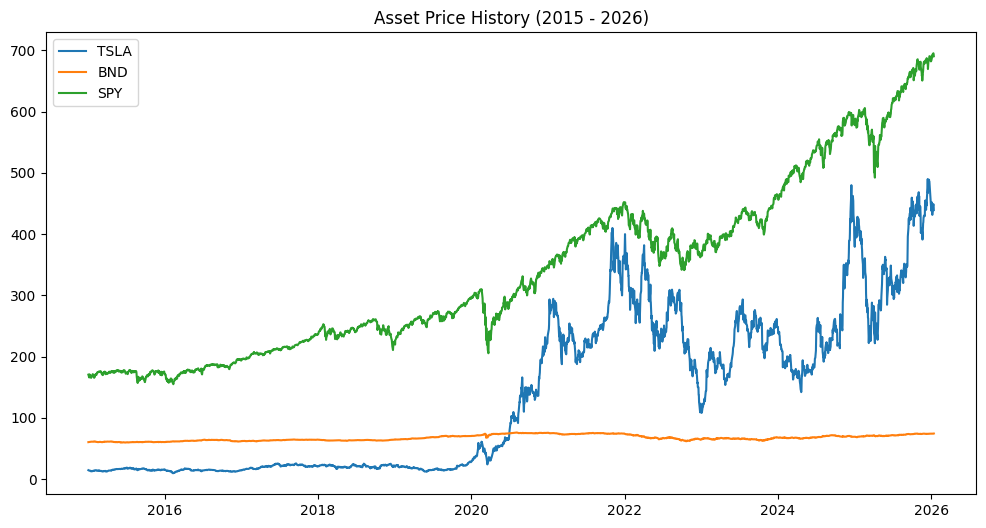

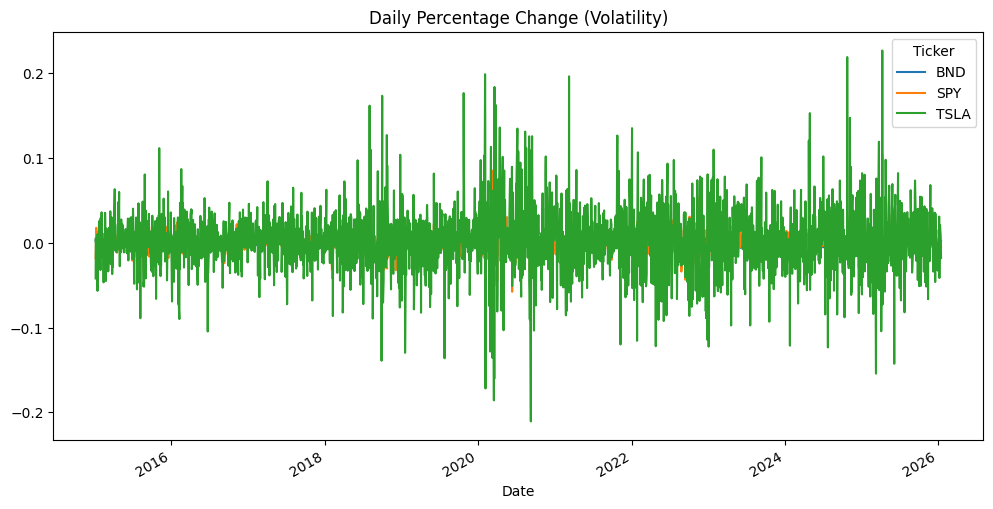

In [5]:
import matplotlib.pyplot as plt

# 1. Visualize the Closing Price 
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(cleaned_data[ticker], label=ticker)
plt.title("Asset Price History (2015 - 2026)")
plt.legend()
plt.show()

# 2. Calculate Daily Returns 
# This shows the percentage change from one day to the next
daily_returns = cleaned_data.pct_change().dropna()

# 3. Visualize Daily Volatility 
daily_returns.plot(figsize=(12, 6), title="Daily Percentage Change (Volatility)")
plt.show()

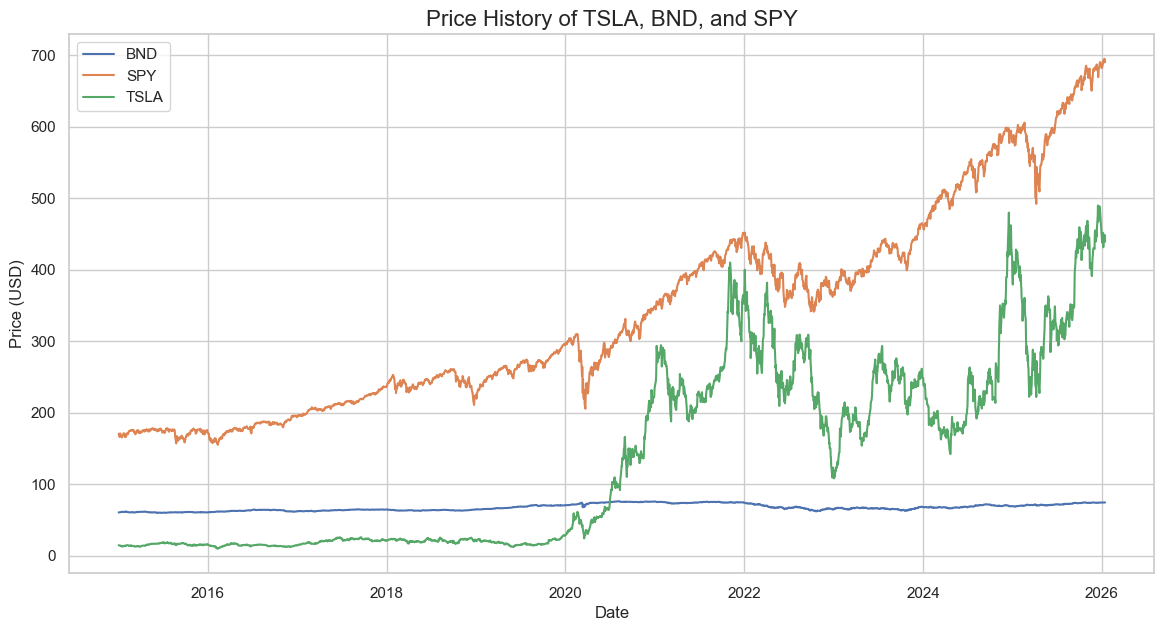

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a nice style for our charts
sns.set_theme(style="whitegrid")

# Plotting the Closing Prices
plt.figure(figsize=(14, 7))
for ticker in cleaned_data.columns:
    plt.plot(cleaned_data[ticker], label=ticker)

plt.title("Price History of TSLA, BND, and SPY", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

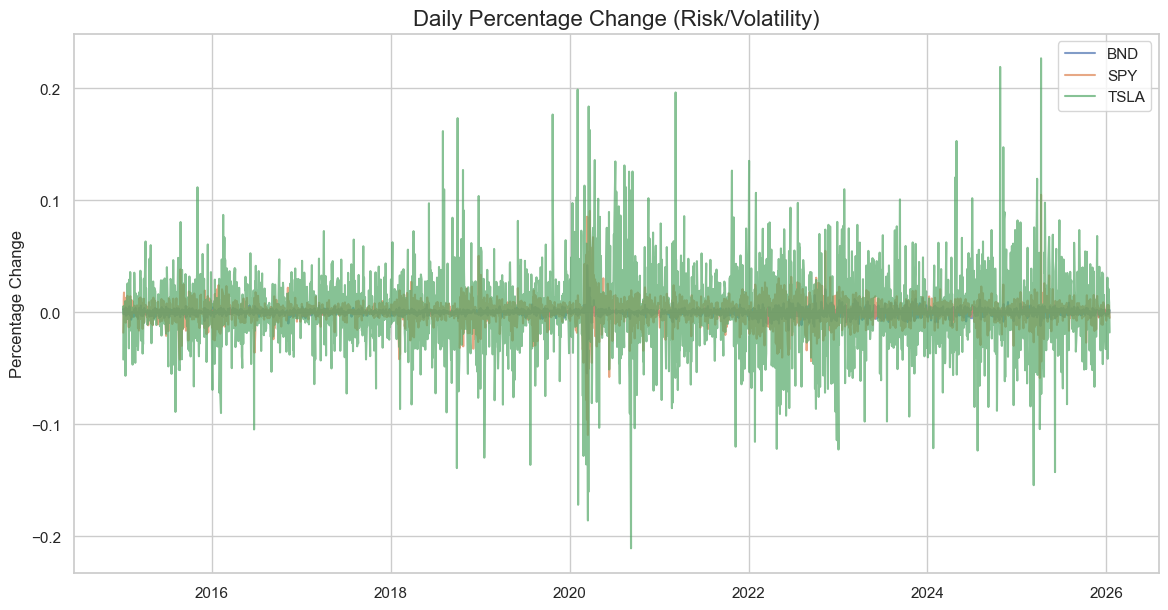

In [7]:
# Calculate daily returns (percentage change)
daily_returns = cleaned_data.pct_change().dropna()

# Plotting the returns
plt.figure(figsize=(14, 7))
for ticker in daily_returns.columns:
    plt.plot(daily_returns[ticker], label=ticker, alpha=0.7)

plt.title("Daily Percentage Change (Risk/Volatility)", fontsize=16)
plt.ylabel("Percentage Change")
plt.legend()
plt.show()

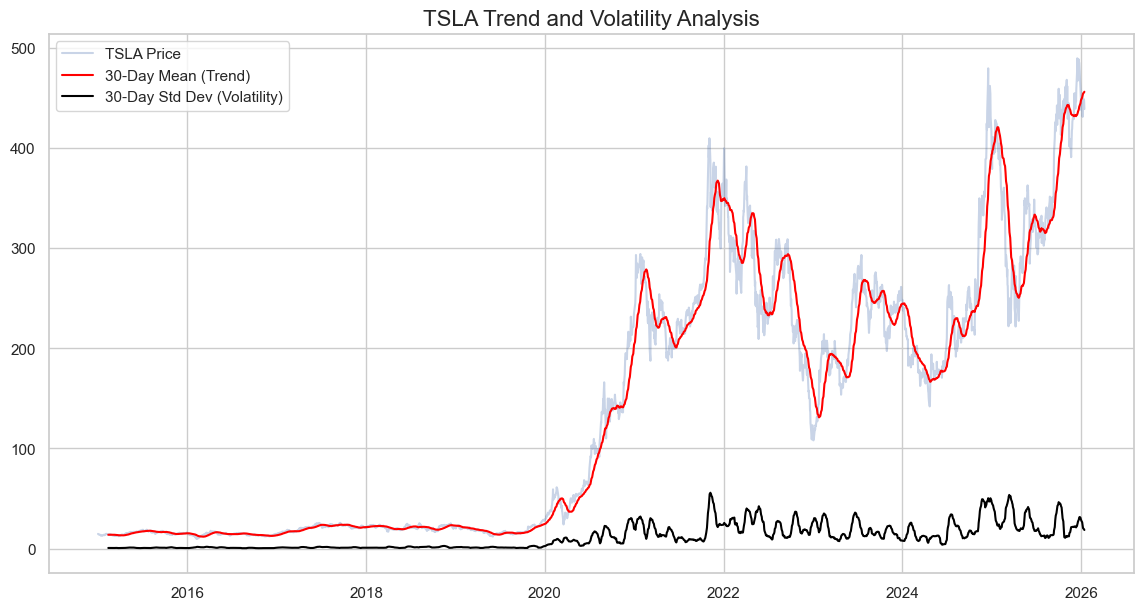

In [8]:
# We'll look at TSLA as an example since it's the most volatile
tsla_rolling_mean = cleaned_data['TSLA'].rolling(window=30).mean()
tsla_rolling_std = cleaned_data['TSLA'].rolling(window=30).std()

plt.figure(figsize=(14, 7))
plt.plot(cleaned_data['TSLA'], label='TSLA Price', alpha=0.3)
plt.plot(tsla_rolling_mean, label='30-Day Mean (Trend)', color='red')
plt.plot(tsla_rolling_std, label='30-Day Std Dev (Volatility)', color='black')
plt.title("TSLA Trend and Volatility Analysis", fontsize=16)
plt.legend()
plt.show()

--- Extreme Market Days (Outliers) ---
Ticker           BND       SPY      TSLA
Date                                    
2025-04-04       NaN -0.058543       NaN
2025-04-07 -0.012056       NaN       NaN
2025-04-09       NaN  0.105019  0.226900
2025-04-10       NaN -0.043819       NaN
2025-06-05       NaN       NaN -0.142599


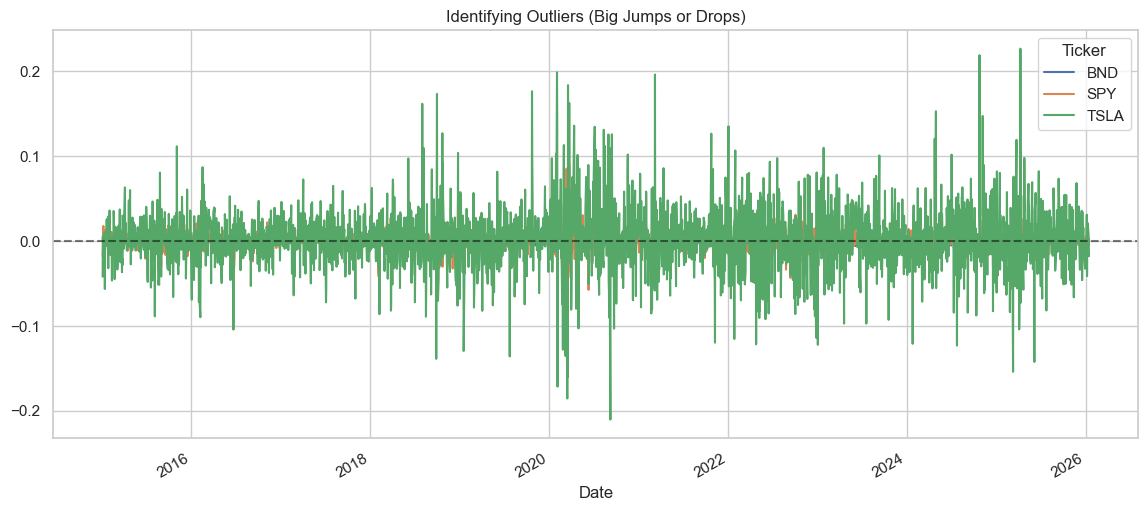

In [9]:
# Detect outliers (days where returns were extreme)
# We calculate how many standard deviations away each day is from the mean
outliers = daily_returns[(daily_returns.abs() > (daily_returns.mean() + 3 * daily_returns.std()))].dropna(how='all')

print("--- Extreme Market Days (Outliers) ---")
print(outliers.tail())

# Let's visualize these big jumps
daily_returns.plot(figsize=(14, 6))
plt.title("Identifying Outliers (Big Jumps or Drops)")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Result: Stationary (Ready for modeling!)")
    else:
        print("Result: Not Stationary (Needs more cleaning/differencing)")

# Test the Closing Prices (usually NOT stationary)
check_stationarity(cleaned_data['TSLA'], "TSLA Price")

# Test the Daily Returns (usually ARE stationary)
check_stationarity(daily_returns['TSLA'], "TSLA Daily Returns")

--- ADF Test for TSLA Price ---
ADF Statistic: -0.7802
p-value: 0.8249
Result: Not Stationary (Needs more cleaning/differencing)
--- ADF Test for TSLA Daily Returns ---
ADF Statistic: -53.0196
p-value: 0.0000
Result: Stationary (Ready for modeling!)


In [11]:
import numpy as np

# Calculate Annualized Sharpe Ratio (assuming 252 trading days)
# Higher is better!
excess_return = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)
sharpe_ratio = excess_return / annual_volatility

print("--- Sharpe Ratios ---")
print(sharpe_ratio)

--- Sharpe Ratios ---
Ticker
BND     0.381459
SPY     0.803992
TSLA    0.823185
dtype: float64
